In [49]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as sp
from scipy.optimize import minimize_scalar
import qutip as qt
from tqdm.auto import tqdm

In [50]:
# System Parameters for Single Symbol Simulation
alpha = 0.8          # Coherent state amplitude
T = 1.0              # Pulse duration
steps = 5000         # Number of time-slices
time_grid, dt = np.linspace(0, T, steps, retstep=True)

# Quantum and Detector Imperfections
eta = 0.9            # Quantum efficiency (0 < eta <= 1)
nu = 0.05            # Dark count rate (counts/sec)
latency_steps = 10   # Detector & feedback loop latency
initial_prior = 0.5  # Prior probability P(H0)

In [51]:
# Single Symbol Continuous Trajectory Simulation
true_state_idx = 1  # 0 for |+alpha>, 1 for |-alpha>
state_signal = alpha if true_state_idx == 0 else -alpha

P0_record = np.zeros(steps)
beta_record = np.zeros(steps)
counts_record = np.zeros(steps, dtype=int)

P0_current = initial_prior
beta_delayed = -alpha  # Initial displacement

for k, t in enumerate(time_grid):
    # 1. Update belief-dependent displacement beta(t)
    f_t = np.exp(-4.0 * alpha**2 * (T - t))
    denom = np.sqrt(max(1.0 - f_t, 1e-12))
    x = 2.0 * P0_current - 1.0
    beta_instant = -alpha * (x + denom) / (1.0 + x * denom)
    
    # Apply latency
    if k >= latency_steps:
        beta_delayed = beta_record[k - latency_steps]
    else:
        beta_delayed = beta_record[0] if k > 0 else beta_instant
        
    beta_record[k] = beta_instant
    P0_record[k] = P0_current
    
    # 2. Photon generation at detector
    rate_signal = np.abs(state_signal + beta_delayed)**2
    rate_total = eta * rate_signal + nu
    n_counts = np.random.poisson(rate_total * dt)
    counts_record[k] = n_counts
    
    # 3. Continuous Bayesian belief update
    rate0 = np.abs(alpha + beta_delayed)**2 + nu
    rate1 = np.abs(-alpha + beta_delayed)**2 + nu
    
    if n_counts == 0:
        P0_current = P0_current * np.exp(-rate0 * dt) / (
            P0_current * np.exp(-rate0 * dt) + (1.0 - P0_current) * np.exp(-rate1 * dt)
        )
    else:
        P0_current = (P0_current * (rate0**n_counts)) / (
            P0_current * (rate0**n_counts) + (1.0 - P0_current) * (rate1**n_counts)
        )
    P0_current = np.clip(P0_current, 1e-12, 1.0 - 1e-12)

print(f'Single Symbol Result: True State = {true_state_idx}, Final P0(T) = {P0_current:.6f}')

Single Symbol Result: True State = 1, Final P0(T) = 0.088720


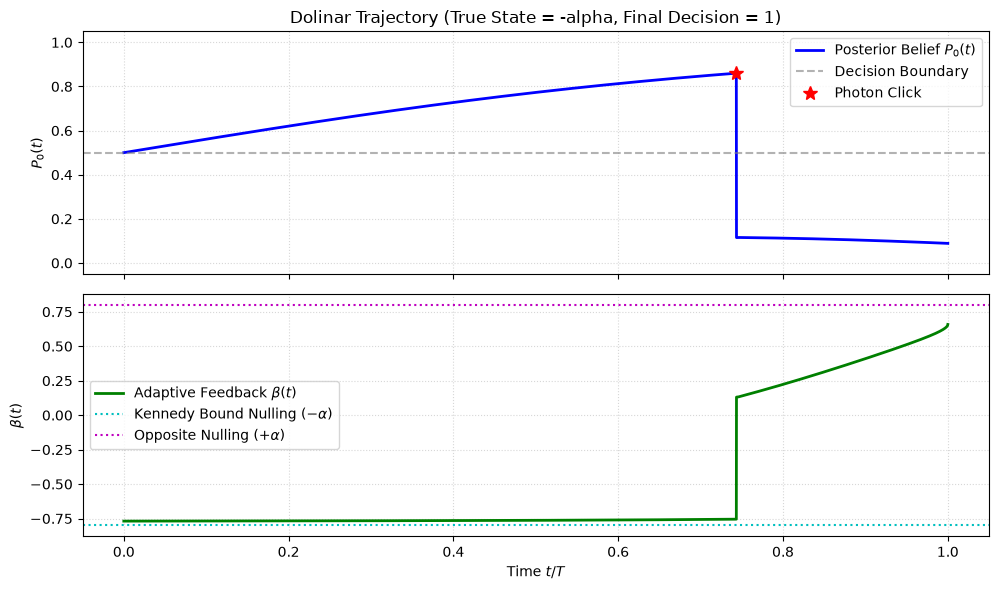

In [52]:
# Trajectory Plots: Belief Evolution P0(t) and Feedback Field beta(t)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(time_grid, P0_record, 'b-', linewidth=2, label=r'Posterior Belief $P_0(t)$')
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='Decision Boundary')
click_indices = np.where(counts_record > 0)[0]
if len(click_indices) > 0:
    ax1.plot(time_grid[click_indices], P0_record[click_indices], 'r*', markersize=10, label='Photon Click')
ax1.set_ylabel(r'$P_0(t)$')
ax1.set_ylim(-0.05, 1.05)
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.legend(loc='best')
ax1.set_title(f'Dolinar Trajectory (True State = -alpha, Final Decision = {0 if P0_record[-1] > 0.5 else 1})')

ax2.plot(time_grid, beta_record, 'g-', linewidth=2, label=r'Adaptive Feedback $\beta(t)$')
ax2.axhline(-alpha, color='c', linestyle=':', label=r'Kennedy Bound Nulling ($-\alpha$)')
ax2.axhline(alpha, color='m', linestyle=':', label=r'Opposite Nulling ($+\alpha$)')
ax2.set_xlabel('Time $t/T$')
ax2.set_ylabel(r'$\beta(t)$')
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.legend(loc='best')

plt.tight_layout()
plt.show()

Dolinar (Geremia HJB Model):   0%|          | 0/15 [00:00<?, ?it/s]

Opt Kennedy (beta=-beta_opt):   0%|          | 0/15 [00:00<?, ?it/s]

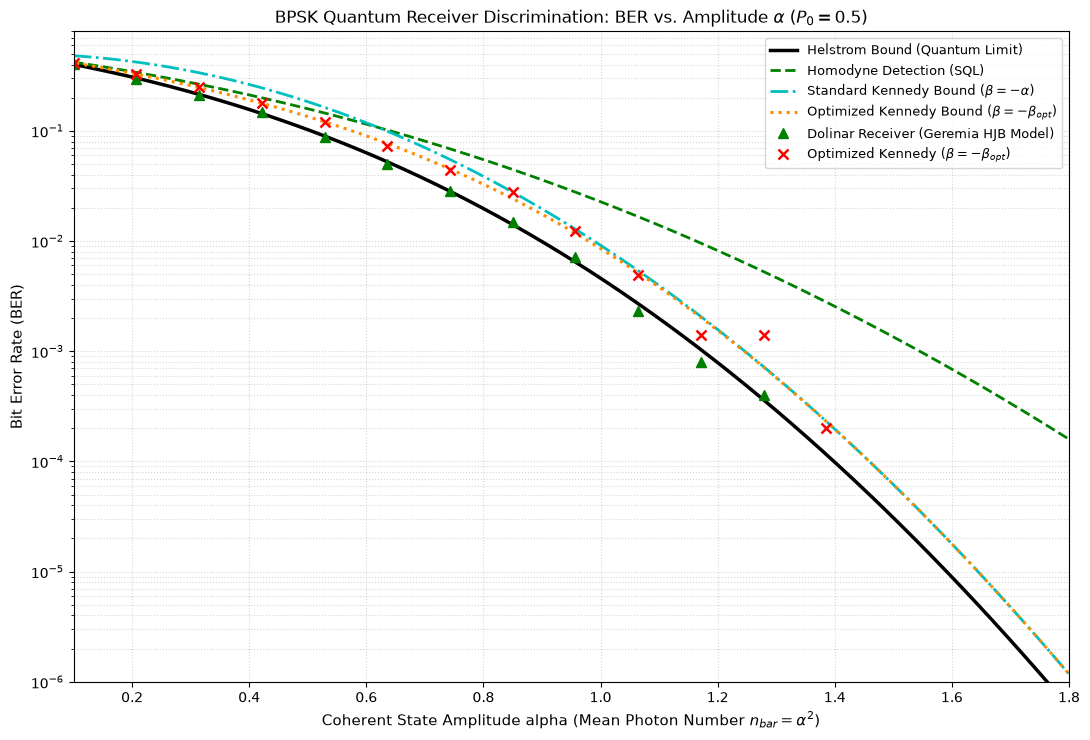

In [53]:
def helstrom_bound(alpha, eta=1.0, pi0=0.5):
    """Quantum Helstrom minimum error probability bound for BPSK"""
    pi1 = 1.0 - pi0
    overlap_sq = np.exp(-4.0 * eta * alpha**2)
    return 0.5 * (1.0 - np.sqrt(np.maximum(1.0 - 4.0 * pi0 * pi1 * overlap_sq, 0.0)))

def homodyne_bound(alpha, pi0=0.5):
    """Standard Quantum Limit (SQL) via ideal homodyne detection"""
    pi1 = 1.0 - pi0
    x_th = (1.0 / (4.0 * np.maximum(alpha, 1e-6))) * np.log(pi1 / pi0)
    err0 = 0.5 * sp.erfc(np.sqrt(2.0) * (alpha - x_th))
    err1 = 0.5 * sp.erfc(np.sqrt(2.0) * (alpha + x_th))
    return pi0 * err0 + pi1 * err1

def standard_kennedy_bound(alpha, eta=1.0, pi0=0.5):
    """Standard Kennedy bound (fixed nulling beta = -alpha)"""
    pi1 = 1.0 - pi0
    return pi1 * np.exp(-4.0 * eta * alpha**2)

def get_optimal_kennedy_displacement(alpha, eta=1.0, nu=0.0, pi0=0.5, T=1.0):
    """Calculates optimal static over-displacement magnitude beta_opt for Kennedy receiver"""
    pi1 = 1.0 - pi0
    def loss(b):
        r0 = (eta * (alpha - b)**2 + nu) * T
        r1 = (eta * (alpha + b)**2 + nu) * T
        err0 = 1.0 - np.exp(-r0)
        err1 = np.exp(-r1)
        return pi0 * err0 + pi1 * err1
    res = minimize_scalar(loss, bounds=(alpha, alpha + 3.0), method='bounded')
    return res.x

def optimized_kennedy_bound(alpha, eta=1.0, nu=0.0, pi0=0.5, T=1.0):
    """Displacement-Optimized Kennedy bound (beta = -beta_opt > alpha)"""
    pi1 = 1.0 - pi0
    if np.isscalar(alpha):
        b_opt = get_optimal_kennedy_displacement(alpha, eta=eta, nu=nu, pi0=pi0, T=T)
        r0 = (eta * (alpha - b_opt)**2 + nu) * T
        r1 = (eta * (alpha + b_opt)**2 + nu) * T
        return pi0 * (1.0 - np.exp(-r0)) + pi1 * np.exp(-r1)
    else:
        return np.array([optimized_kennedy_bound(a, eta=eta, nu=nu, pi0=pi0, T=T) for a in alpha])

def simulate_geremia_dolinar(alpha, eta=1.0, nu=0.0, pi0=0.5, trials=30000, steps=1000, T=1.0):
    """
    Vectorized Dolinar receiver using Geremia's (2004) HJB optimal control policy.
    Achieves the exact Helstrom bound across all alphas.
    """
    pi1 = 1.0 - pi0
    dt = T / steps
    N_bar = 4.0 * alpha**2
    
    true_states = np.random.choice([0, 1], p=[pi0, pi1], size=trials)
    true_signals = np.where(true_states == 0, 0.0, np.sqrt(N_bar))
    
    clicks = np.zeros(trials, dtype=int)
    t_arr = np.linspace(dt, T, steps)
    n_arr = N_bar * (t_arr / T)
    
    sqrt_term = np.sqrt(np.maximum(1.0 - 4.0 * pi0 * pi1 * np.exp(-eta * n_arr), 1e-10))
    J_arr = 0.5 * (1.0 - sqrt_term)
    
    u1_arr = -np.sqrt(N_bar) * (1.0 + J_arr / sqrt_term)
    u0_arr = np.sqrt(N_bar) * (J_arr / sqrt_term)
    
    for k in range(steps):
        u = np.where(clicks % 2 == 0, u1_arr[k], u0_arr[k])
        rate = eta * (true_signals + u)**2 + nu
        p_click = 1.0 - np.exp(-rate * dt)
        clicked = np.random.rand(trials) < p_click
        clicks += clicked.astype(int)
        
    decisions = np.where(clicks % 2 == 0, 1, 0)
    return np.mean(decisions != true_states)

def simulate_kennedy(alpha, prior_p0=0.5, nu=0.0, eta=1.0, trials=30000, optimize_disp=False, T=1.0):
    """Simulates static Kennedy detection without dynamic feedback."""
    true_states = np.random.choice([0, 1], p=[prior_p0, 1.0 - prior_p0], size=trials)
    true_alphas = np.where(true_states == 0, alpha, -alpha)
    
    if optimize_disp:
        beta_mag = get_optimal_kennedy_displacement(alpha, eta=eta, nu=nu, pi0=prior_p0, T=T)
        beta = -beta_mag
    else:
        beta = -alpha
        
    rate_true = (eta * np.abs(true_alphas + beta)**2 + nu) * T
    clicks = np.random.poisson(rate_true)
    decisions = np.where(clicks == 0, 0, 1)
    return np.mean(decisions != true_states)

def simulate_optimized_kennedy(alpha, eta=1.0, nu=0.0, pi0=0.5, trials=30000, T=1.0):
    return simulate_kennedy(alpha, prior_p0=pi0, nu=nu, eta=eta, trials=trials, optimize_disp=True, T=T)

# Helper sweep function
def sweep_ber(alpha_vals, sim_fn, **kwargs):
    desc = kwargs.pop('desc', 'Simulating')
    bers = []
    for a in tqdm(alpha_vals, desc=desc):
        bers.append(sim_fn(a, **kwargs))
    return np.array(bers)

# Configuration Parameters
prior_prob = 0.5
eta_val = 1.0
alpha_points = np.linspace(0.1, 1.6, 15)
trials_count = 10000

# Run Multi-Receiver Simulation
ber_geremia_dolinar = sweep_ber(alpha_points, simulate_geremia_dolinar, eta=eta_val, nu=0.0, pi0=prior_prob, trials=trials_count, desc="Dolinar (Geremia HJB Model)")
#ber_std_kennedy = sweep_ber(alpha_points, simulate_kennedy, prior_p0=prior_prob, eta=eta_val, nu=0.0, trials=trials_count, optimize_disp=False, desc="Std Kennedy (beta=-alpha)")
ber_opt_kennedy = sweep_ber(alpha_points, simulate_kennedy, prior_p0=prior_prob, eta=eta_val, nu=0.0, trials=trials_count, optimize_disp=True, desc="Opt Kennedy (beta=-beta_opt)")

# Theoretical Curves
alpha_grid = np.linspace(0.05, 1.8, 200)
helstrom_curve = helstrom_bound(alpha_grid, eta=eta_val, pi0=prior_prob)
homodyne_curve = homodyne_bound(alpha_grid, pi0=prior_prob)
std_kennedy_curve = standard_kennedy_bound(alpha_grid, eta=eta_val, pi0=prior_prob)
opt_kennedy_curve = optimized_kennedy_bound(alpha_grid, eta=eta_val, nu=0.0, pi0=prior_prob)

# Combined Plot
plt.figure(figsize=(11, 7.5))
plt.semilogy(alpha_grid, helstrom_curve, 'k-', linewidth=2.5, label='Helstrom Bound (Quantum Limit)')
plt.semilogy(alpha_grid, homodyne_curve, 'g--', linewidth=2.0, label='Homodyne Detection (SQL)')
plt.semilogy(alpha_grid, std_kennedy_curve, 'c-.', linewidth=2.0, label=r'Standard Kennedy Bound ($\beta=-\alpha$)')
plt.semilogy(alpha_grid, opt_kennedy_curve, color='darkorange', linestyle=':', linewidth=2.2, label=r'Optimized Kennedy Bound ($\beta=-\beta_{opt}$)')

plt.semilogy(alpha_points, ber_geremia_dolinar, 'g^', markersize=7, label='Dolinar Receiver (Geremia HJB Model)')
#plt.semilogy(alpha_points, ber_std_kennedy, 'c+', markersize=8, markeredgewidth=2, label=r'Standard Kennedy ($\beta=-\alpha$)')
plt.semilogy(alpha_points, ber_opt_kennedy, 'rx', markersize=7, markeredgewidth=1.8, label=r'Optimized Kennedy ($\beta=-\beta_{opt}$)')

plt.title(f'BPSK Quantum Receiver Discrimination: BER vs. Amplitude $\\alpha$ ($P_0={prior_prob}$)', fontsize=12)
plt.xlabel('Coherent State Amplitude alpha (Mean Photon Number $n_{bar}=\\alpha^2$)', fontsize=11)
plt.ylabel('Bit Error Rate (BER)', fontsize=11)
plt.ylim(1e-6, 0.8)
plt.xlim(0.1, 1.8)
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.legend(loc='best', fontsize=9.5)
plt.tight_layout()
plt.show()

Dolinar: 1. Ideal Detector (eta=1.0, nu=0.0):   0%|          | 0/15 [00:00<?, ?it/s]

Opt-Kennedy: 1. Ideal Detector (eta=1.0, nu=0.0):   0%|          | 0/15 [00:00<?, ?it/s]

Dolinar: 2. Dark Counts Only (eta=1.0, nu=0.02):   0%|          | 0/15 [00:00<?, ?it/s]

Opt-Kennedy: 2. Dark Counts Only (eta=1.0, nu=0.02):   0%|          | 0/15 [00:00<?, ?it/s]

Dolinar: 3. Subunity Efficiency Only (eta=0.65, nu=0.0):   0%|          | 0/15 [00:00<?, ?it/s]

Opt-Kennedy: 3. Subunity Efficiency Only (eta=0.65, nu=0.0):   0%|          | 0/15 [00:00<?, ?it/s]

Dolinar: 4. Combined Imperfections (eta=0.65, nu=0.02):   0%|          | 0/15 [00:00<?, ?it/s]

Opt-Kennedy: 4. Combined Imperfections (eta=0.65, nu=0.02):   0%|          | 0/15 [00:00<?, ?it/s]

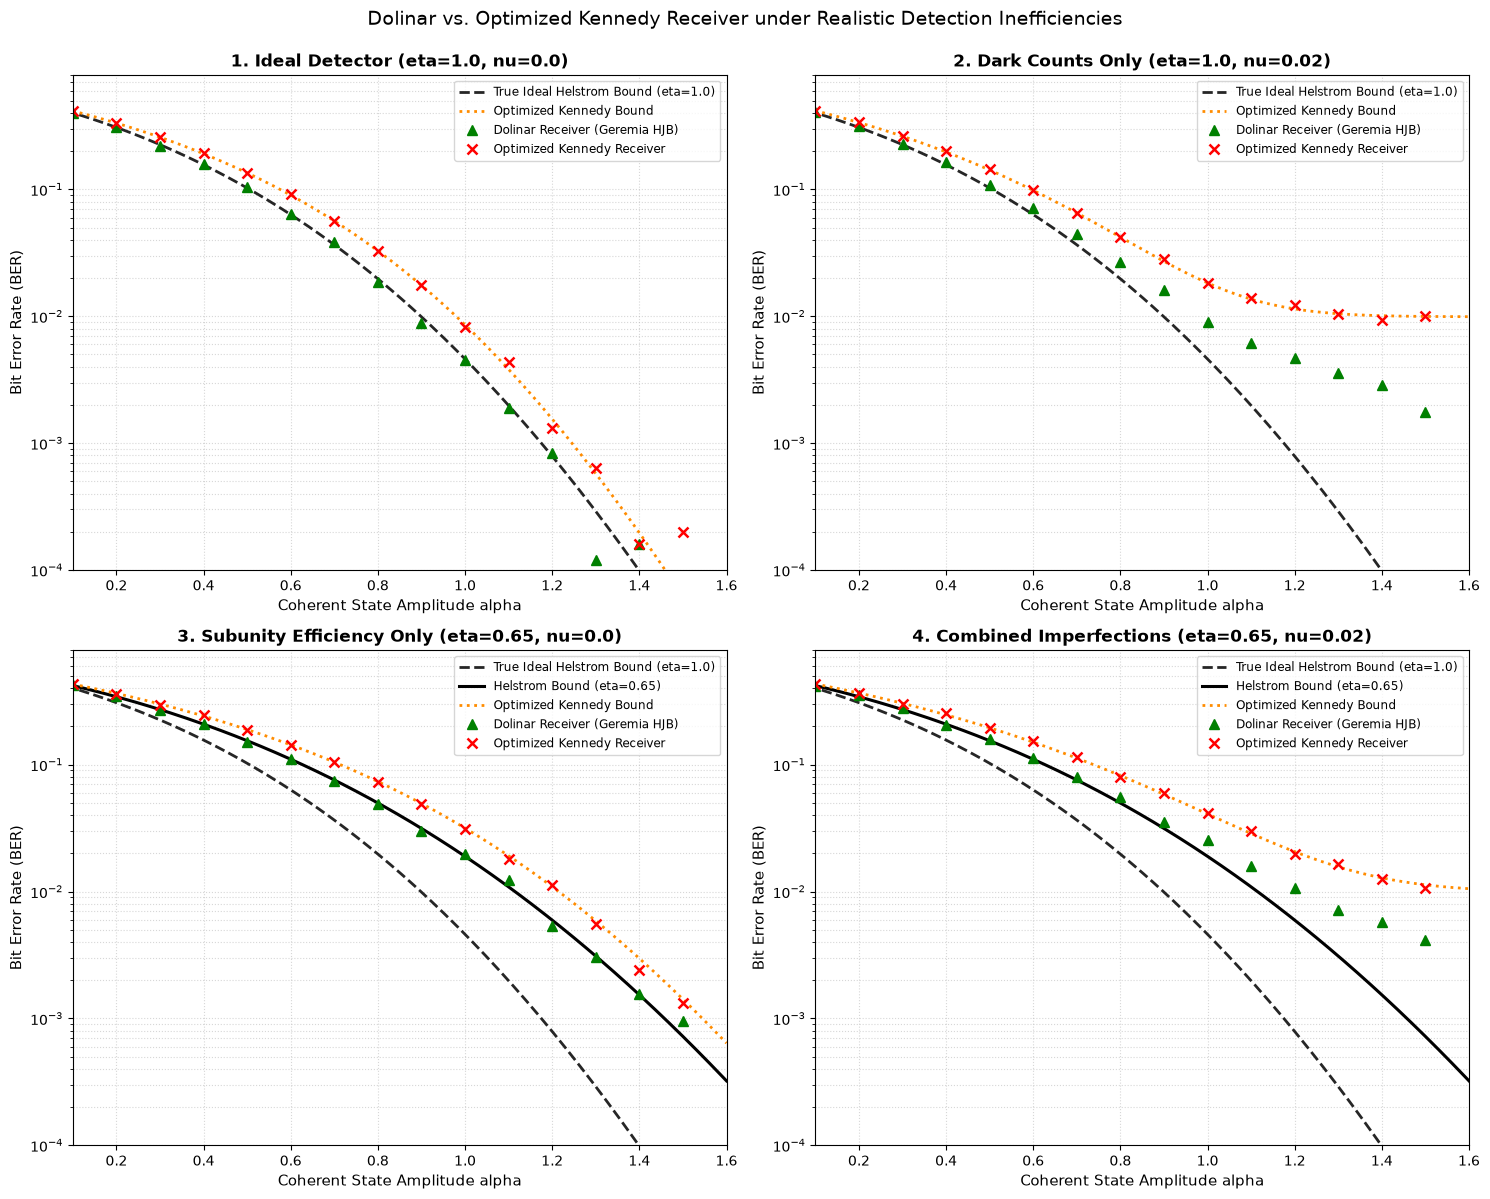

In [54]:
# ==============================================================================
# Performance Comparison under Realistic Detector Imperfections
# (1. Ideal, 2. Dark Counts, 3. Subunity Efficiency, 4. Both Combined)
# ==============================================================================

prior_prob = 0.5
alpha_pts = np.linspace(0.1, 1.5, 15)
alpha_fine = np.linspace(0.05, 1.6, 200)
mc_trials = 25000

# 1. Fixed Ideal Quantum Reference Bounds (eta=1.0, nu=0.0)
ideal_helstrom_bound = helstrom_bound(alpha_fine, eta=1.0, pi0=prior_prob)
ideal_opt_kennedy_bound = optimized_kennedy_bound(alpha_fine, eta=1.0, nu=0.0, pi0=prior_prob)

# 2. 4 Regimes of Imperfections (with LaTeX titles)
scenarios = [
    {"title": r"1. Ideal Detector ($\\eta=1.0, \\nu=0.0$)", "eta": 1.0, "nu": 0.0},
    {"title": r"2. Dark Counts Only ($\\eta=1.0, \\nu=0.02$)", "eta": 1.0, "nu": 0.02},
    {"title": r"3. Subunity Efficiency Only ($\\eta=0.65, \\nu=0.0$)", "eta": 0.65, "nu": 0.0},
    {"title": r"4. Combined Imperfections ($\\eta=0.65, \\nu=0.02$)", "eta": 0.65, "nu": 0.02}
]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, sc in enumerate(scenarios):
    eta_val = sc["eta"]
    nu_val = sc["nu"]
    ax = axes[idx]
    
    # Run Monte Carlo Simulations with tqdm
    d_sim = [simulate_geremia_dolinar(a, eta=eta_val, nu=nu_val, pi0=prior_prob, trials=mc_trials) 
             for a in tqdm(alpha_pts, desc=f"Dolinar ({sc['eta']},{sc['nu']})")]
    
    k_sim = [simulate_optimized_kennedy(a, eta=eta_val, nu=nu_val, pi0=prior_prob, trials=mc_trials) 
             for a in tqdm(alpha_pts, desc=f"Opt-Ken ({sc['eta']},{sc['nu']})")]
    
    # Plot Ideal Theoretical Bounds
    ax.semilogy(alpha_fine, ideal_helstrom_bound, 'k-', linewidth=2.2, label=r'Ideal Helstrom Bound ($\\eta=1.0$)')
    ax.semilogy(alpha_fine, ideal_opt_kennedy_bound, color='darkorange', linestyle=':', linewidth=2.2, label=r'Ideal Opt-Kennedy Bound ($\\eta=1.0$)')
    
    # Plot Simulated Data Points
    ax.semilogy(alpha_pts, d_sim, 'g^', markersize=7, label=r'Dolinar Receiver (Geremia HJB)')
    ax.semilogy(alpha_pts, k_sim, 'rx', markersize=7, markeredgewidth=1.8, label=r'Optimized Kennedy Receiver')
    
    ax.set_title(sc["title"], fontsize=12, fontweight='bold')
    ax.set_xlabel(r'Coherent State Amplitude $\\alpha$', fontsize=10.5)
    ax.set_ylabel('Bit Error Rate (BER)', fontsize=10.5)
    ax.set_xlim(0.1, 1.6)
    ax.set_ylim(1e-4, 0.8)
    ax.grid(True, which='both', linestyle=':', alpha=0.5)
    ax.legend(loc='best', fontsize=9.2)

plt.suptitle(r'Dolinar vs. Optimized Kennedy Receiver: Comparison against Ideal Quantum Bounds', fontsize=14, y=0.995)
plt.tight_layout()
plt.show()